In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


# ==========================================
# 1. Load the dataset
# ==========================================


In [2]:
filename = 'Dataset/spambase_csv.csv'
df = pd.read_csv(filename)

# Identify target and features
target_col = 'class'  # Identified from your CSV
feature_cols = [col for col in df.columns if col != target_col]

print("Step 1: Dataset Loaded.")
print(f"Shape: {df.shape} (Rows, Columns)")
print(df.head())
print("-" * 30)

Step 1: Dataset Loaded.
Shape: (4601, 58) (Rows, Columns)
   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_%3B  char_freq_%28  \
0        

# ==========================================
# 2. Perform data preprocessing 
# (Handling missing values and Scaling)
# ==========================================

In [3]:
# # A. Handling Missing Values
# # Even if your current dataset has no missing values, this step ensures robustness
# imputer = SimpleImputer(strategy='mean')
# df[feature_cols] = imputer.fit_transform(df[feature_cols])

# B. Scaling
# Spambase data varies widely (e.g., percentages vs. run lengths), so scaling is vital.
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

print("Step 2: Preprocessing Complete (Imputation & Standardization).")
print("-" * 30)

Step 2: Preprocessing Complete (Imputation & Standardization).
------------------------------


# ==========================================
# 3. Perform Exploratory Data Analysis (EDA)
# ==========================================

In [4]:
print("Step 3: Statistical Summary")
print(df.describe()) # Summary stats (mean, std, min, max)

# Check for missing values
print("\nMissing Values Check:")
print(df.isnull().sum().sum())
print("-" * 30)


Step 3: Statistical Summary
       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
count     4601.000000        4601.000000    4601.000000   4601.000000   
mean         0.104553           0.213015       0.280656      0.065425   
std          0.305358           1.290575       0.504143      1.395151   
min          0.000000           0.000000       0.000000      0.000000   
25%          0.000000           0.000000       0.000000      0.000000   
50%          0.000000           0.000000       0.000000      0.000000   
75%          0.000000           0.000000       0.420000      0.000000   
max          4.540000          14.280000       5.100000     42.810000   

       word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
count    4601.000000     4601.000000       4601.000000         4601.000000   
mean        0.312223        0.095901          0.114208            0.105295   
std         0.672513        0.273824          0.391441            0.401071   
mi

# ==========================================
# 4. Visualize class distribution and feature behavior
# ==========================================


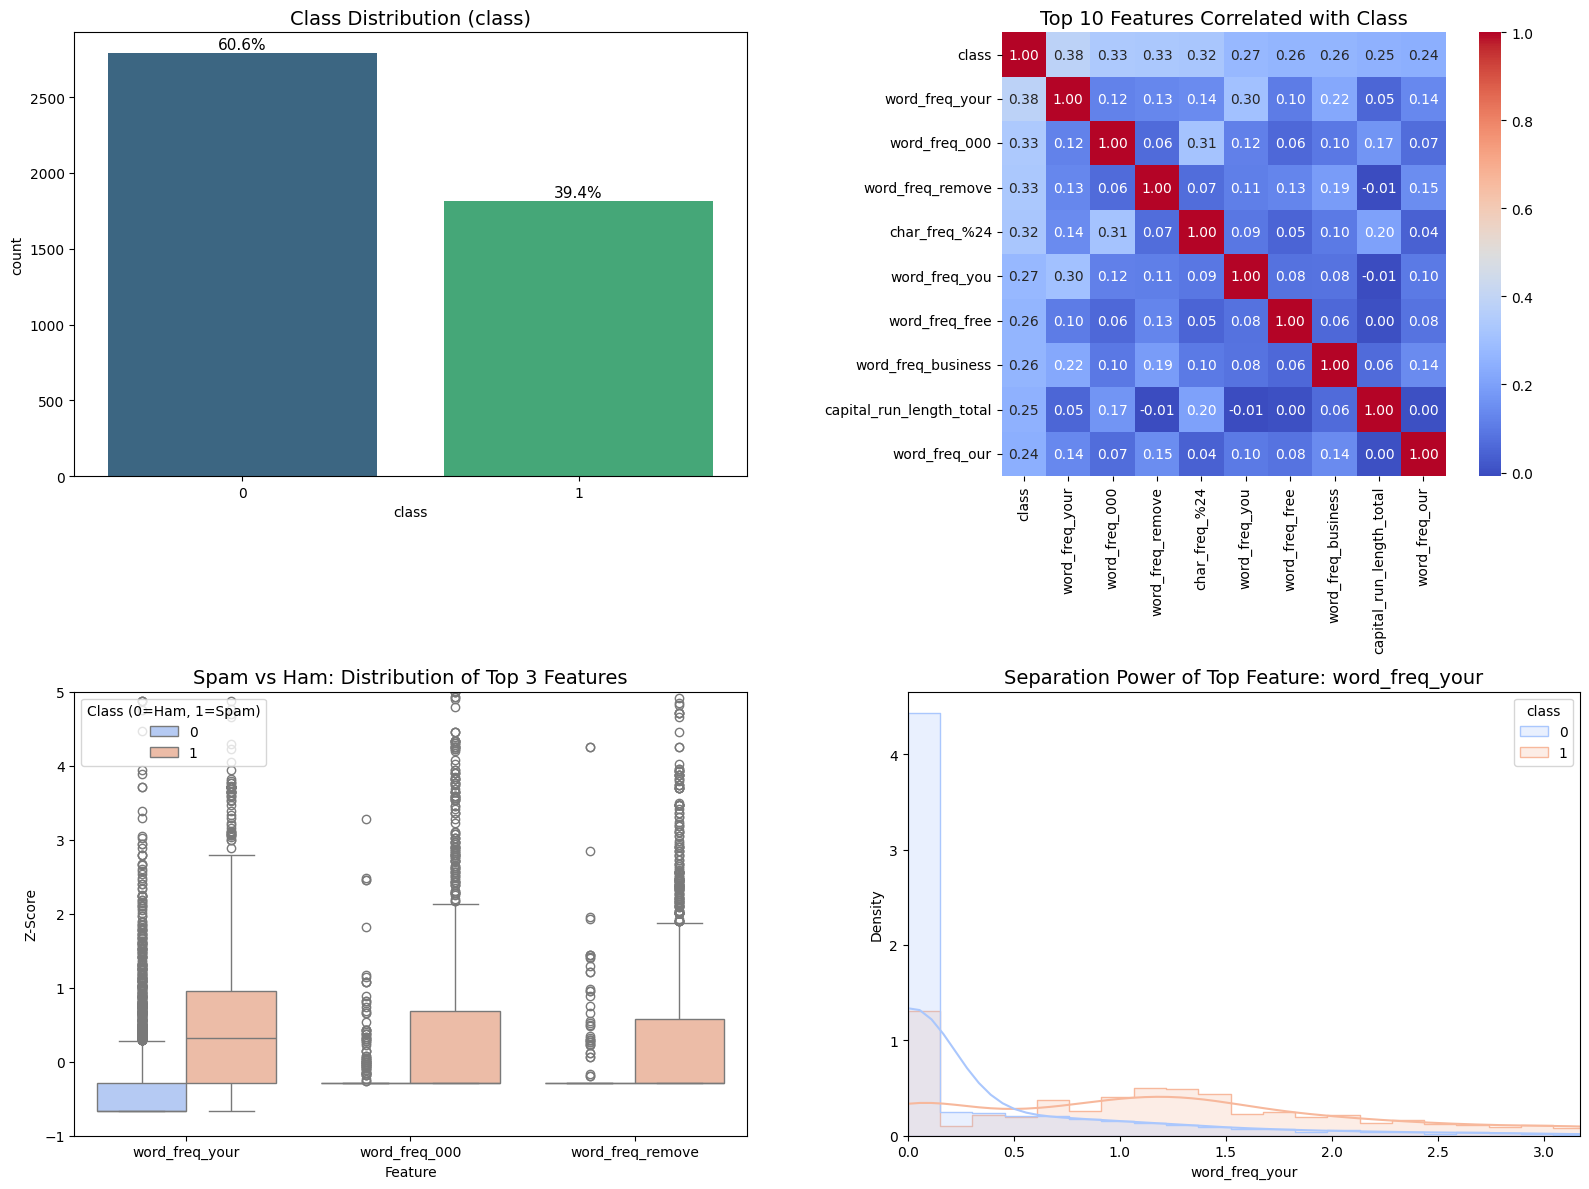

In [5]:


plt.figure(figsize=(16, 12))

# --- A. Class Distribution (With Percentages) ---
plt.subplot(2, 2, 1)
ax = sns.countplot(x=target_col,hue=target_col, data=df, palette='viridis',legend=False)
plt.title(f'Class Distribution ({target_col})', fontsize=14)
# Add percentage annotations
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 30,
            f'{100 * height / total:.1f}%', ha="center", fontsize=11)

# --- B. Feature Behavior: Correlation Heatmap ---
plt.subplot(2, 2, 2)
k = 10 
# Select top k features most correlated with target
cols = df.corr().nlargest(k, target_col)[target_col].index
cm = np.corrcoef(df[cols].values.T)
sns.heatmap(cm, annot=True, square=True, fmt='.2f', 
            yticklabels=cols.values, xticklabels=cols.values, 
            cmap='coolwarm', annot_kws={"size": 10})
plt.title(f'Top {k} Features Correlated with Class', fontsize=14)

# --- C. Feature Behavior: Grouped Box Plot (Spam vs Ham) ---
# IMPROVEMENT: Compare classes side-by-side for the Top 3 features
plt.subplot(2, 2, 3)
# Identify top 3 features (excluding target)
top_3_features = cols[1:4] 
# Melt data to plot multiple features on one graph
df_melted = df_scaled.melt(id_vars=target_col, value_vars=top_3_features, 
                           var_name='Feature', value_name='Z-Score')
sns.boxplot(x='Feature', y='Z-Score', hue=target_col, data=df_melted, palette='coolwarm')
plt.title('Spam vs Ham: Distribution of Top 3 Features', fontsize=14)
plt.ylim(-1, 5) # Zoom in to ignore extreme outliers
plt.legend(title='Class (0=Ham, 1=Spam)')

# --- D. Feature Behavior: Grouped Histogram ---
# IMPROVEMENT: Overlay distributions to show separation
plt.subplot(2, 2, 4)
top_feature = top_3_features[0] # The #1 predictor
sns.histplot(data=df, x=top_feature, hue=target_col, kde=True, 
             element="step", stat="density", common_norm=False, palette='coolwarm')
plt.title(f'Separation Power of Top Feature: {top_feature}', fontsize=14)
plt.xlim(0, df[top_feature].quantile(0.95)) # Cut off extreme tail for visibility

plt.tight_layout()
plt.show()

# ==========================================
# 5. Split the dataset into training and testing sets
# ==========================================

In [6]:
X = df_scaled[feature_cols]
y = df_scaled[target_col]

# 70-30 split is standard for this dataset size (~4600 rows)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Step 5: Data Split Successfully.")
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Step 5: Data Split Successfully.
Training set shape: (3220, 57)
Testing set shape: (1381, 57)



# ==========================================
# 6. Train Naive Bayes Variants
# ==========================================

In [7]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import time

# --- Data Preparation ---
# StandardScaler for Gaussian/Bernoulli/KNN
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

# MinMaxScaler for MultinomialNB (requires non-negative features)
scaler_mm = MinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

# Dictionary to store all model results for final comparison
model_performance = {}

def train_eval_model(model, X_tr, y_tr, X_te, y_te, name):
    start_train = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - start_train
    
    start_pred = time.time()
    y_pred = model.predict(X_te)
    pred_time = time.time() - start_pred
    
    accuracy = accuracy_score(y_te, y_pred)
    
    # Store model and predictions for later visualization
    model_performance[name] = {
        'model': model,
        'accuracy': accuracy,
        'y_pred': y_pred,
        'y_proba': model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None,
        'train_time': train_time,
        'pred_time': pred_time
    }
    print(f"{name} trained. Accuracy: {accuracy:.4f}")

# --- Train NB Variants ---
print("--- Training Naive Bayes Variants ---")
train_eval_model(GaussianNB(), X_train_std, y_train, X_test_std, y_test, 'GaussianNB')
train_eval_model(MultinomialNB(), X_train_mm, y_train, X_test_mm, y_test, 'MultinomialNB')
train_eval_model(BernoulliNB(), X_train_std, y_train, X_test_std, y_test, 'BernoulliNB')

--- Training Naive Bayes Variants ---
GaussianNB trained. Accuracy: 0.8182
MultinomialNB trained. Accuracy: 0.8849
BernoulliNB trained. Accuracy: 0.9022


# ==========================================
# 7 & 8: Train Baseline KNN & Hyperparameter Tuning
# ==========================================


--- Training Baseline KNN ---
KNN (Baseline) trained. Accuracy: 0.8965

--- Hyperparameter Tuning for KNN ---
Optimal k found: 5


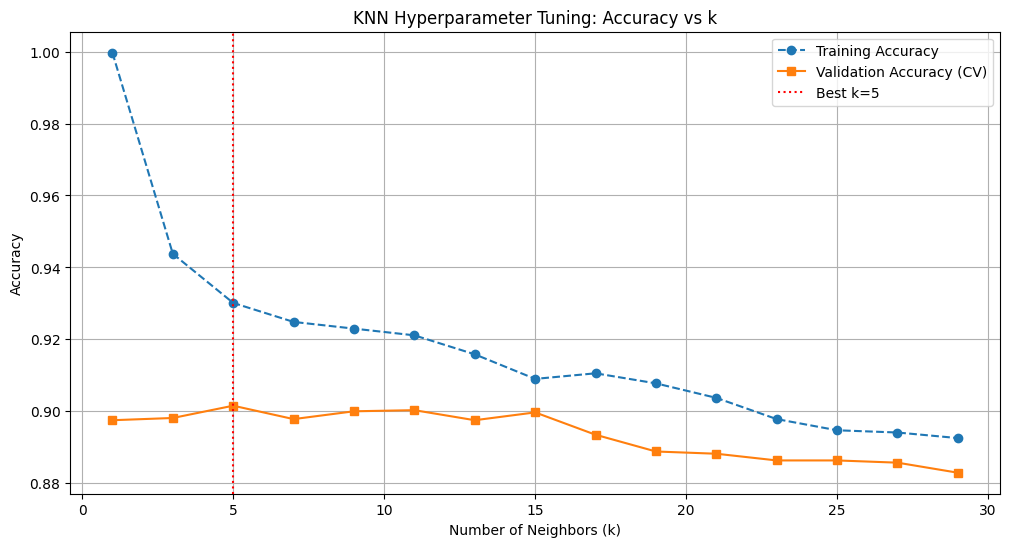

In [8]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# --- 7. Baseline KNN (Default k=5) ---
print("\n--- Training Baseline KNN ---")
train_eval_model(KNeighborsClassifier(), X_train_std, y_train, X_test_std, y_test, 'KNN (Baseline)')

# --- 8. Hyperparameter Tuning (Finding Best k) ---
print("\n--- Hyperparameter Tuning for KNN ---")
k_values = range(1, 31, 2) # Test odd k from 1 to 29
train_accuracies = []
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Validation Accuracy (Cross-Validation)
    scores = cross_val_score(knn, X_train_std, y_train, cv=5, scoring='accuracy')
    val_accuracies.append(scores.mean())
    
    # Training Accuracy
    knn.fit(X_train_std, y_train)
    train_accuracies.append(knn.score(X_train_std, y_train))

# Identify Best k
best_k = k_values[np.argmax(val_accuracies)]
print(f"Optimal k found: {best_k}")

# --- PLOT: Accuracy vs k & Train vs Validation ---
plt.figure(figsize=(12, 6))
plt.plot(k_values, train_accuracies, label='Training Accuracy', marker='o', linestyle='--')
plt.plot(k_values, val_accuracies, label='Validation Accuracy (CV)', marker='s')
plt.axvline(best_k, color='red', linestyle=':', label=f'Best k={best_k}')
plt.title('KNN Hyperparameter Tuning: Accuracy vs k')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# Step 9: Train Optimized KNN Models
# ==========================================

In [9]:
# --- 9. Train Optimized KNN Models ---
print(f"\n--- Training Optimized KNN Models (k={best_k}) ---")

# KNN with KDTree
knn_kd = KNeighborsClassifier(n_neighbors=best_k, algorithm='kd_tree')
train_eval_model(knn_kd, X_train_std, y_train, X_test_std, y_test, 'KNN (KDTree)')

# KNN with BallTree
knn_ball = KNeighborsClassifier(n_neighbors=best_k, algorithm='ball_tree')
train_eval_model(knn_ball, X_train_std, y_train, X_test_std, y_test, 'KNN (BallTree)')


--- Training Optimized KNN Models (k=5) ---
KNN (KDTree) trained. Accuracy: 0.8965
KNN (BallTree) trained. Accuracy: 0.8965


# ==========================================
# Step 10: Evaluation & Visualizations
# ==========================================

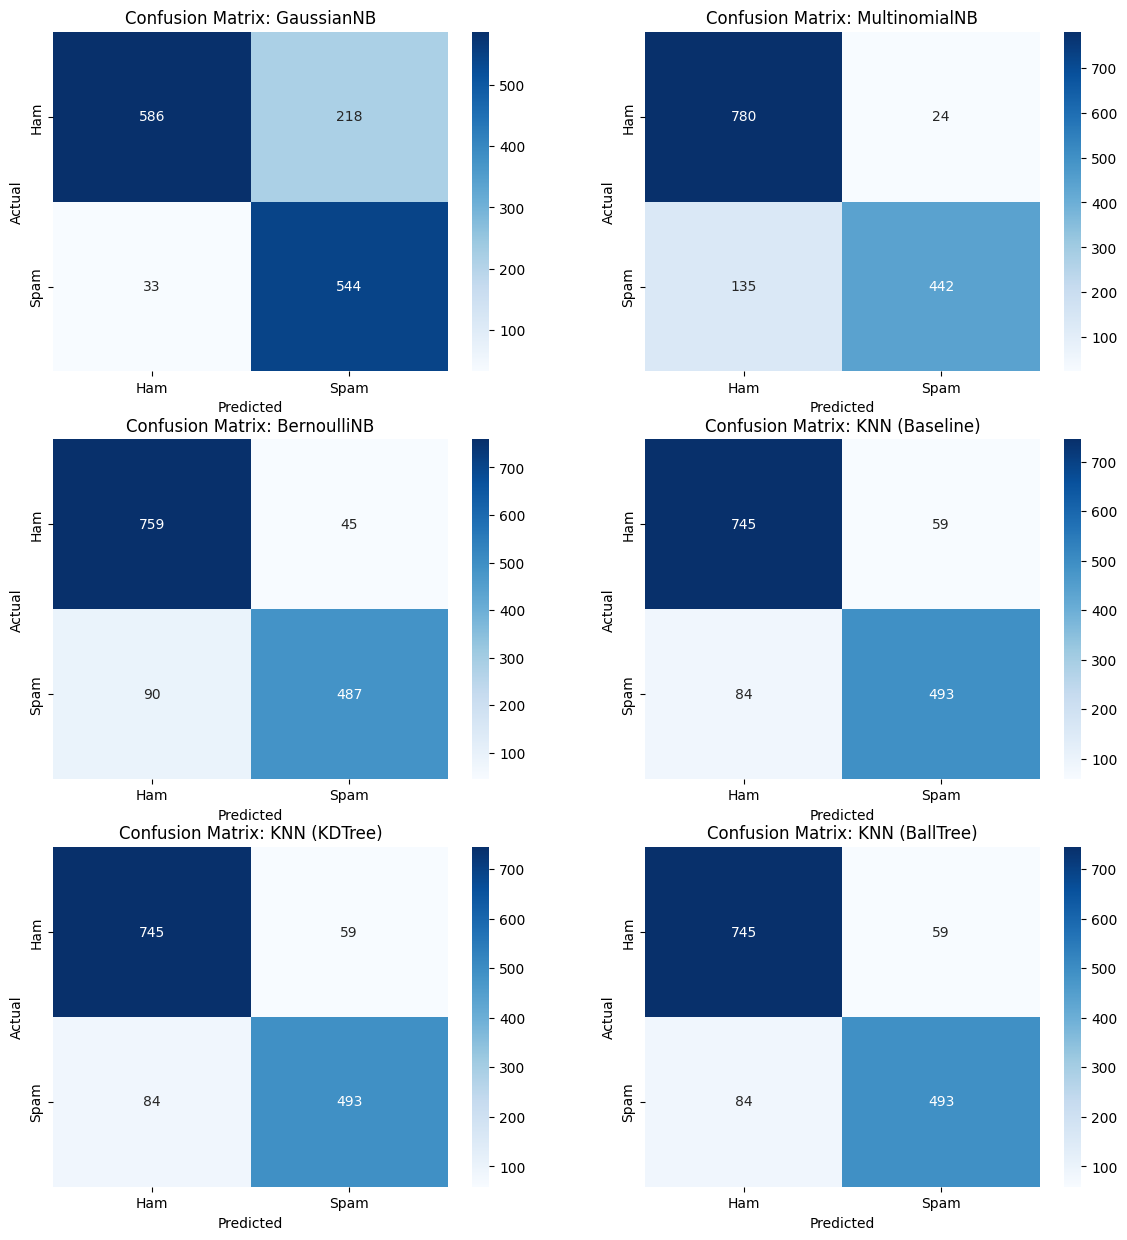

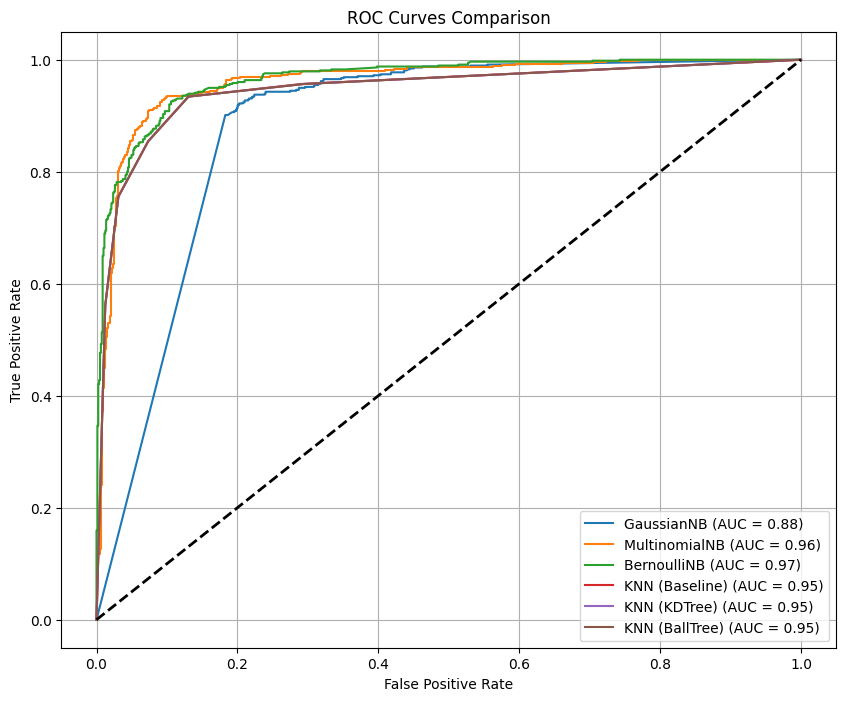

<Figure size 640x480 with 0 Axes>


--- Final Performance Metrics ---


,Model,Accuracy,Precision,Recall,F1 Score,Specificity,False Positive Rate,Training Time (s),Prediction Time (s)
2,BernoulliNB,0.902245,0.915414,0.844021,0.878269,0.944030,0.055970,0.002728,0.001032
3,KNN (Baseline),0.896452,0.893116,0.854419,0.873339,0.926617,0.073383,0.001422,2.045491
4,KNN (KDTree),0.896452,0.893116,0.854419,0.873339,0.926617,0.073383,0.017782,0.191041
5,KNN (BallTree),0.896452,0.893116,0.854419,0.873339,0.926617,0.073383,0.010952,0.197302
1,MultinomialNB,0.884866,0.948498,0.766031,0.847555,0.970149,0.029851,0.002990,0.000931
0,GaussianNB,0.818248,0.713911,0.942808,0.812547,0.728856,0.271144,0.003792,0.001045


In [10]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score

# --- Evaluate All Models ---
metrics_list = []

plt.figure(figsize=(10, 8)) # For ROC Curve

# Setup for Confusion Matrix Subplots
n_models = len(model_performance)
rows = (n_models + 1) // 2
fig_cm, axes_cm = plt.subplots(rows, 2, figsize=(14, 5 * rows))
axes_cm = axes_cm.flatten()

for i, (name, info) in enumerate(model_performance.items()):
    y_pred = info['y_pred']
    y_proba = info['y_proba']
    
    # Calculate Metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    specificity = tn / (tn + fp)
    fpr = fp / (tn + fp)
    
    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Specificity': specificity,
        'False Positive Rate': fpr,
        'Training Time (s)': info['train_time'],
        'Prediction Time (s)': info['pred_time']
    })
    
    # 1. Plot Confusion Matrix
    sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt='d', cmap='Blues', ax=axes_cm[i])
    axes_cm[i].set_title(f'Confusion Matrix: {name}')
    axes_cm[i].set_xlabel('Predicted')
    axes_cm[i].set_ylabel('Actual')
    axes_cm[i].set_xticklabels(['Ham', 'Spam'])
    axes_cm[i].set_yticklabels(['Ham', 'Spam'])

    # 2. Plot ROC Curve (if probability is available)
    if y_proba is not None:
        fpr_roc, tpr_roc, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr_roc, tpr_roc)
        plt.figure(1) # Switch to ROC figure
        plt.plot(fpr_roc, tpr_roc, label=f'{name} (AUC = {roc_auc:.2f})')

# Finalize ROC Plot
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Finalize Confusion Matrix Plot
plt.figure(fig_cm.number)
plt.tight_layout()
plt.show()

# --- Display Performance Metrics DataFrame ---
metrics_df = pd.DataFrame(metrics_list)
print("\n--- Final Performance Metrics ---")
display(metrics_df.sort_values(by='F1 Score', ascending=False))

--- Performing Bias-Variance Analysis ---

Bias-Variance Decomposition Proxy:


,Model,Train Accuracy,Test Accuracy,Bias (Train Error),Variance (Gap),Status
2,BernoulliNB,0.901553,0.902245,0.098447,-0.000692,Good Fit
3,KNN (Baseline),0.930124,0.896452,0.069876,0.033672,Good Fit
4,KNN (KDTree),0.930124,0.896452,0.069876,0.033672,Good Fit
5,KNN (BallTree),0.930124,0.896452,0.069876,0.033672,Good Fit
1,MultinomialNB,0.889441,0.884866,0.110559,0.004575,Good Fit
0,GaussianNB,0.808385,0.818248,0.191615,-0.009863,Good Fit


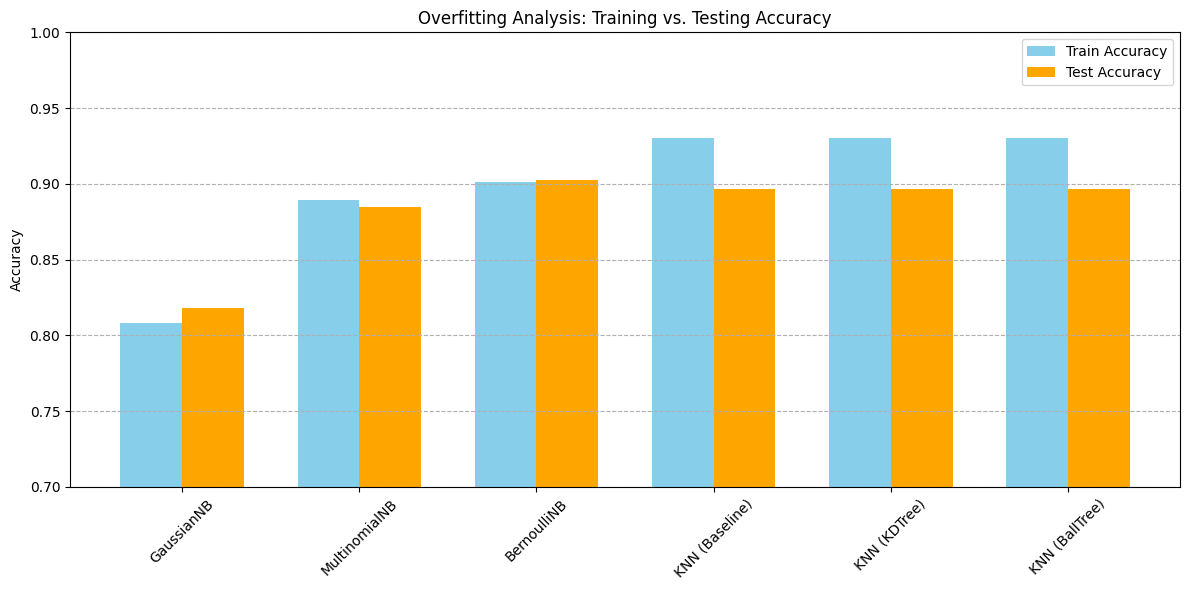

In [11]:
# --- 11. Overfitting & Bias-Variance Analysis ---
print("--- Performing Bias-Variance Analysis ---")

analysis_results = []

for name, info in model_performance.items():
    model = info['model']
    
    # Check if model was trained on Standard or MinMax data
    # (We infer this based on the model name or simply re-score using the correct set)
    if 'MultinomialNB' in name:
        train_acc = model.score(X_train_mm, y_train)
    else:
        train_acc = model.score(X_train_std, y_train)
        
    test_acc = info['accuracy']
    
    # Calculate Bias and Variance Proxies
    # Bias ~ (1 - Training Accuracy)
    # Variance ~ (Training Accuracy - Test Accuracy)
    bias = 1 - train_acc
    variance = train_acc - test_acc
    
    analysis_results.append({
        'Model': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Bias (Train Error)': bias,
        'Variance (Gap)': variance,
        'Status': 'Overfitting' if variance > 0.05 else ('Underfitting' if train_acc < 0.80 else 'Good Fit')
    })

# Convert to DataFrame
bv_df = pd.DataFrame(analysis_results)

# Display Table
print("\nBias-Variance Decomposition Proxy:")
display(bv_df.sort_values(by='Test Accuracy', ascending=False))

# --- PLOT: Train vs Test Accuracy ---
plt.figure(figsize=(12, 6))
x = np.arange(len(bv_df))
width = 0.35

plt.bar(x - width/2, bv_df['Train Accuracy'], width, label='Train Accuracy', color='skyblue')
plt.bar(x + width/2, bv_df['Test Accuracy'], width, label='Test Accuracy', color='orange')

plt.xticks(x, bv_df['Model'], rotation=45)
plt.ylabel('Accuracy')
plt.title('Overfitting Analysis: Training vs. Testing Accuracy')
plt.legend()
plt.ylim(0.7, 1.0) # Zoom in to see the gap
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# --- 1. Grid Search ---
print("Running Grid Search...")
# Testing all k values from 1 to 30
param_grid = {'n_neighbors': range(1, 31)}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(), 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1 # Use all processors
)
grid_search.fit(X_train_std, y_train)

# --- 2. Randomized Search ---
print("Running Randomized Search...")
# Testing 10 random k values between 1 and 50
param_dist = {'n_neighbors': range(1, 51)}

random_search = RandomizedSearchCV(
    estimator=KNeighborsClassifier(), 
    param_distributions=param_dist, 
    n_iter=10, # Try 10 random combinations
    cv=5, 
    scoring='accuracy', 
    random_state=42, 
    n_jobs=-1
)
random_search.fit(X_train_std, y_train)

# --- 3. Create Table 2 ---
tuning_results = [
    {
        'Search Method': 'Grid Search',
        'Best k': grid_search.best_params_['n_neighbors'],
        'Best CV Accuracy': grid_search.best_score_,
        'Best Parameters': str(grid_search.best_params_)
    },
    {
        'Search Method': 'Randomized Search',
        'Best k': random_search.best_params_['n_neighbors'],
        'Best CV Accuracy': random_search.best_score_,
        'Best Parameters': str(random_search.best_params_)
    }
]

# Create DataFrame
table_2 = pd.DataFrame(tuning_results)

# Display formatted table
print("\nTable 2: KNN Hyperparameter Tuning")
display(table_2)

Running Grid Search...
Running Randomized Search...

Table 2: KNN Hyperparameter Tuning


,Search Method,Best k,Best CV Accuracy,Best Parameters
0,Grid Search,5,0.901553,{'n_neighbors': 5}
1,Randomized Search,14,0.895031,{'n_neighbors': 14}


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Load and Preprocess Data
df = pd.read_csv('Dataset/spambase_csv.csv')
X = df.drop('class', axis=1)
y = df['class']

# Split and Scale (StandardScaler is crucial for KNN)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)

# 2. Define Hyperparameter Search Space
# We check k values from 1 to 30
param_grid = {'n_neighbors': range(1, 31)}

# 3. Tune KDTree
print("Finding optimal k for KDTree...")
grid_kd = GridSearchCV(
    KNeighborsClassifier(algorithm='kd_tree'),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_kd.fit(X_train_std, y_train)

# 4. Tune BallTree
print("Finding optimal k for BallTree...")
grid_ball = GridSearchCV(
    KNeighborsClassifier(algorithm='ball_tree'),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_ball.fit(X_train_std, y_train)

# 5. Display Comparison
results = pd.DataFrame([
    {
        'Algorithm': 'KD Tree', 
        'Optimal k': grid_kd.best_params_['n_neighbors'], 
        'Best CV Accuracy': grid_kd.best_score_
    },
    {
        'Algorithm': 'Ball Tree', 
        'Optimal k': grid_ball.best_params_['n_neighbors'], 
        'Best CV Accuracy': grid_ball.best_score_
    }
])

print("\n--- Tuning Results ---")
print(results)

Finding optimal k for KDTree...
Finding optimal k for BallTree...

--- Tuning Results ---
   Algorithm  Optimal k  Best CV Accuracy
0    KD Tree          5          0.901553
1  Ball Tree          5          0.901553
